# 01 Exploratory Data Analysis

Goal: understand the Online Retail II dataset before committing to any 
modeling decisions. This notebook answers three layered questions:

1. **What is this data?** Scale, schema, data quality.
2. **What does the data say about the business?** Customer behavior, 
   revenue concentration, time patterns.
3. **What surprises us?** Anomalies that will shape cleaning and 
   feature engineering decisions downstream.

Decisions made here propagate through the entire pipeline, so we go 
slowly and document every choice.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Display settings — make pandas show more
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Setup complete")

Setup complete


## 1 Load the data

The dataset comes as a single Excel file with two sheets covering 
December 2009 through December 2011. We concatenate both into one 
DataFrame. This takes ~30 seconds because Excel parsing is slow; 
once cleaning is done, we'll save as parquet for instant reloads.

In [2]:
# Load both sheets and combine
data_path = Path("../data/raw/online_retail_II.xlsx")

df_2009 = pd.read_excel(data_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(data_path, sheet_name="Year 2010-2011")

print(f"2009-2010: {df_2009.shape[0]:,} rows")
print(f"2010-2011: {df_2010.shape[0]:,} rows")

df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"Combined: {df.shape[0]:,} rows, {df.shape[1]} columns")

2009-2010: 525,461 rows
2010-2011: 541,910 rows
Combined: 1,067,371 rows, 8 columns


## 2 Inspect structure

Before any analysis, understand the schema and dtypes. Key questions:
- What does one row represent? (Spoiler: one line item on one invoice — 
  not one purchase, not one customer.)
- What columns are present and what types?
- Any immediate red flags in the descriptive stats?

The hierarchy we'll work with is: **customer → invoice → line item**. 
A customer can have many invoices; each invoice can have many line items.

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,"1,067,371.00",1067371,"1,067,371.00","824,364.00"
mean,9.94,2011-01-02 21:13:55.394028544,4.65,"15,324.64"
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-07-09 09:46:00,1.25,"13,975.00"
50%,3.00,2010-12-07 15:28:00,2.10,"15,255.00"
75%,10.00,2011-07-22 10:23:00,4.15,"16,797.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,172.71,NaN,123.55,"1,697.46"


## 3 Check missingness

Missing values shape what's possible. For customer segmentation, 
**missing Customer ID is fatal** — we can't segment a customer we 
can't identify. Volume of missingness here determines whether the 
remaining dataset is still meaningful.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)

,count,percent
Customer ID,243007,22.77
Description,4382,0.41


**22% missing Customer IDs**  
A reasonable hypothesis: anonymous web 
orders, returns processed without a linked account, or data entry 
gaps. These rows will be dropped during cleaning, but losing 22% of 
the data is worth flagging in the project README.

## 4 Investigate the weird values

`describe()` showed negative quantities and zero/negative prices. 
Neither is plausible for a normal sale. Two possibilities: data 
quality errors, or systematic encoding of things that aren't sales 
(returns, adjustments, postage). We investigate to choose the right 
cleaning rule by naively dropping all negatives might remove signal 
we want to keep.

In [7]:
# Negative quantities, likely returns
neg_qty = df[df['Quantity'] < 0]
print(f"Negative quantity rows: {len(neg_qty):,} ({len(neg_qty)/len(df)*100:.2f}%)")
neg_qty.head(10)

Negative quantity rows: 22,950 (2.15%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom


In [8]:
# Confirm the pattern
neg_qty['Invoice'].astype(str).str.startswith('C').mean()

0.8493681917211329

**Only 85% of negative-quantity rows are cancellation invoices**   
The other 15% (~3,400 rows) have negative quantities but regular 
invoice numbers. They're not cancellations. Worth investigating: 
data error? Inventory adjustment? Something else?

In [9]:
# What are the non-C negative quantities?
weird_negatives = df[(df['Quantity'] < 0) & (~df['Invoice'].astype(str).str.startswith('C'))]
print(f"Negative qty, non-C invoice: {len(weird_negatives):,} rows")
print(f"\nSample:")
weird_negatives[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(20)

Negative qty, non-C invoice: 3,457 rows

Sample:


,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.00,NaN
283,489463,71477,short,-240,0.00,NaN
284,489467,85123A,21733 mixed,-192,0.00,NaN
470,489521,21646,NaN,-50,0.00,NaN
3114,489655,20683,NaN,-44,0.00,NaN
3162,489660,35956,lost,-1043,0.00,NaN
3168,489663,35605A,damages,-117,0.00,NaN
4296,489806,18010,NaN,-770,0.00,NaN
4538,489820,21133,invcd as 84879?,-720,0.00,NaN
4566,489821,85049G,NaN,-240,0.00,NaN


In [10]:
# Check the hypothesis
print("Descriptions in weird negatives:")
print(weird_negatives['Description'].fillna('(missing)').value_counts().head(15))
print(f"\n% with missing Customer ID: {weird_negatives['Customer ID'].isna().mean():.1%}")

Descriptions in weird negatives:
Description
(missing)                 2689
check                      123
damages                     84
?                           83
damaged                     78
missing                     27
sold as set on dotcom       20
Damaged                     17
Unsaleable, destroyed.       9
smashed                      9
thrown away                  9
dotcom                       8
??                           7
damages?                     7
given away                   6
Name: count, dtype: int64

% with missing Customer ID: 100.0%


**Finding:** the non-cancellation negative quantities are almost 
entirely **internal inventory adjustments** descriptions like 
"check", "damages", "?", "missing", "thrown away". Crucially, they 
all have missing Customer IDs. This means a single cleaning rule like 
"drop rows with missing Customer ID", removes both the missing-ID 
rows in general *and* these inventory adjustments as a subset. 
No separate rule needed.

In [11]:
# Zero or negative prices
zero_price = df[df['Price'] <= 0]
print(f"Rows with price <= 0: {len(zero_price):,}")
zero_price.head(10)

Rows with price <= 0: 6,207


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom


In [12]:
# What stock codes are suspicious?
df['StockCode'].astype(str).str.upper().value_counts().head(20)

StockCode
85123A    5930
22423     4424
85099B    4241
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64

Most stock codes are 5-6 digit alphanumeric IDs, which are real products. 
Inspection reveals non-product codes mixed in: `POST`, `BANK CHARGES`, 
`AMAZONFEE`, `DOT`, `M` (manual), `D` (discount). These are 
administrative entries, not sales. They go on the exclusion list for 
the cleaning step.

## 5 Geographic distribution

The dataset spans multiple countries, but if it's heavily UK-skewed, 
a multi-country analysis adds complexity without proportional insight. 
We check the distribution before committing to scope.

In [13]:
country_summary = df.groupby('Country').agg(
    transactions=('Invoice', 'count'),
    customers=('Customer ID', 'nunique'),
    revenue=('Quantity', lambda x: (x * df.loc[x.index, 'Price']).sum())
).sort_values('revenue', ascending=False)

country_summary.head(15)

,transactions,customers,revenue
Country,,,
United Kingdom,981330,5410,"16,382,583.90"
EIRE,17866,5,"615,519.55"
Netherlands,5140,23,"548,524.95"
Germany,17624,107,"417,988.56"
France,14330,95,"328,191.80"
Australia,1913,15,"167,129.07"
Switzerland,3189,22,"99,728.76"
Spain,3811,41,"91,859.48"
Sweden,1364,19,"87,809.42"


**~92% of revenue is from the UK.** Other countries contribute small, 
inconsistent slices.

**Scope decision:** filter to UK-only for the main analysis. This 
gives us cleaner customer behavior to model (one country, one 
currency, one set of holidays) and avoids the noise of tiny per-country 
segments. The multi-country breakdown is documented in the README as 
a deliberate scope choice, not an oversight.

## 6 Time patterns

How does the business pulse over time? Look for seasonality (do we 
need seasonal features?), trends (is the business growing?), and 
weekly patterns (when do customers buy?).

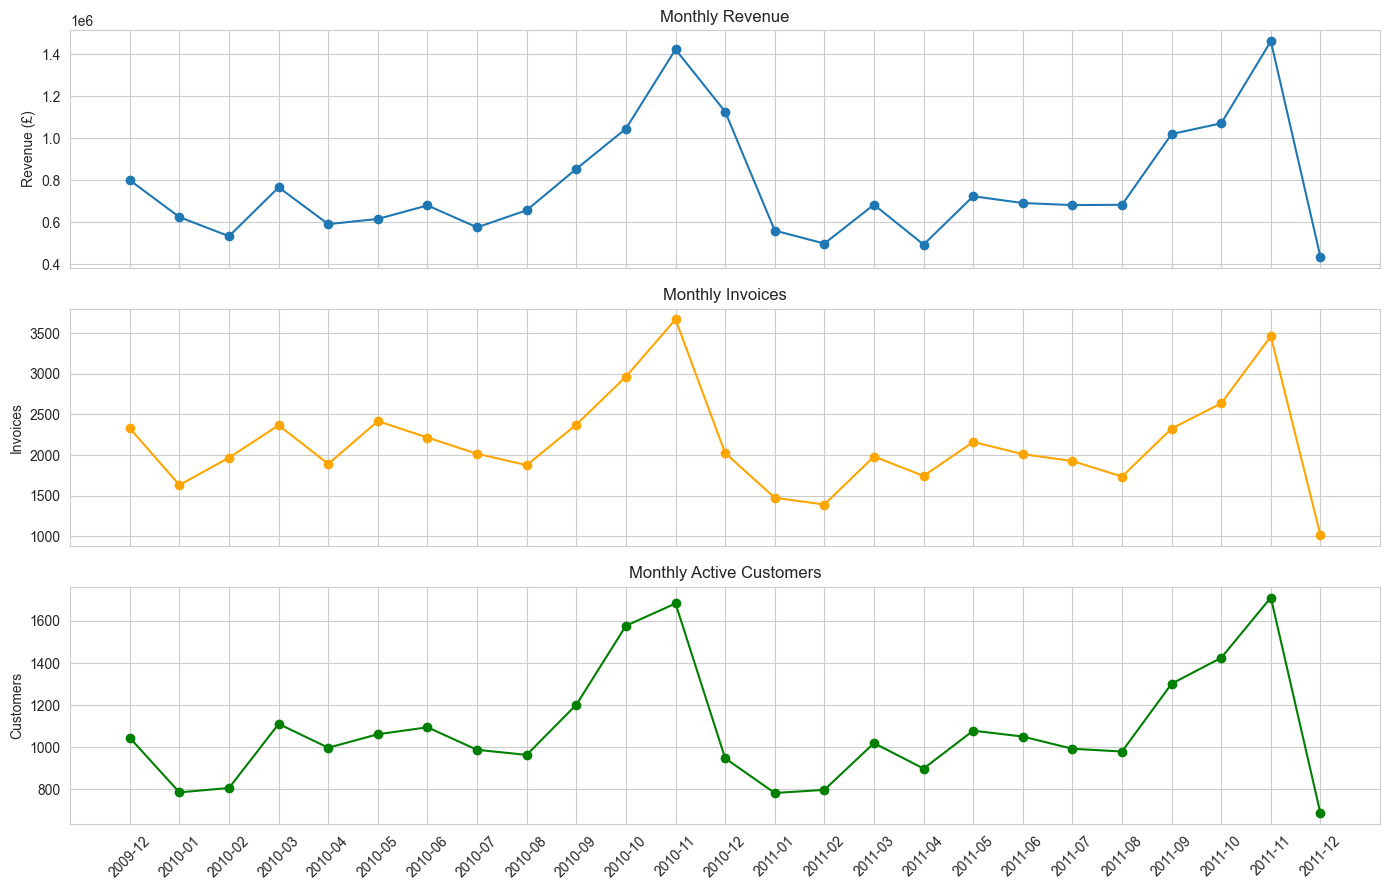

In [14]:
# Add a revenue column for convenience
df['Revenue'] = df['Quantity'] * df['Price']

# Monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month').agg(
    revenue=('Revenue', 'sum'),
    transactions=('Invoice', 'nunique'),
    customers=('Customer ID', 'nunique')
).reset_index()
monthly['Month'] = monthly['Month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(monthly['Month'], monthly['revenue'], marker='o')
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue (£)')
axes[1].plot(monthly['Month'], monthly['transactions'], marker='o', color='orange')
axes[1].set_title('Monthly Invoices')
axes[1].set_ylabel('Invoices')
axes[2].plot(monthly['Month'], monthly['customers'], marker='o', color='green')
axes[2].set_title('Monthly Active Customers')
axes[2].set_ylabel('Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

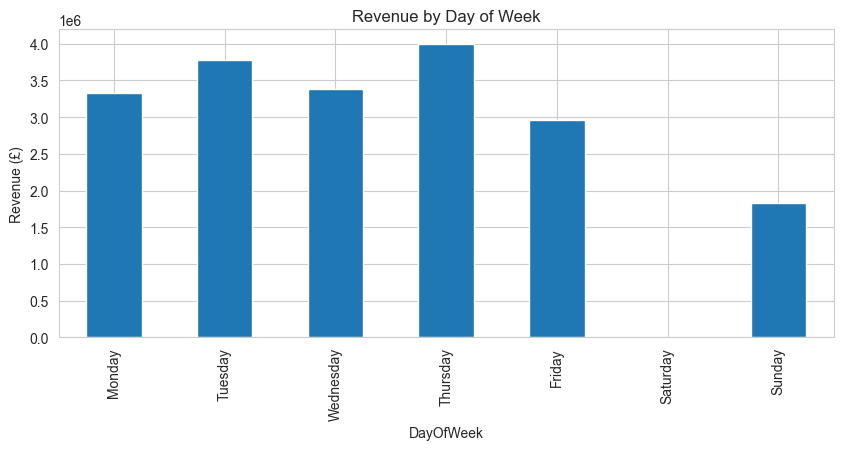

In [15]:
# Day of week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
dow_revenue.plot(kind='bar', figsize=(10, 4), title='Revenue by Day of Week')
plt.ylabel('Revenue (£)')
plt.show()

**The retailer doesn't operate on Saturdays.** Zero revenue on Sat 
across all years. This is a business fact, not a data issue. Sunday 
also looks sparse compared to weekdays. This rules out a 
"weekend purchase ratio" feature as having useful discriminative 
power — most customers can't have weekend orders even if they wanted to.

## 7 Customer behavior distribution

Aggregating to the customer level for the first time. This is a 
rough preview — proper feature engineering comes in notebook 03. 
The goal here is to spot anomalies (mega-customers, negative-spend 
customers) that will affect modeling choices later.

In [16]:
# Customer-level summary (rough — proper version comes in feature engineering)
cust = df[df['Customer ID'].notna()].groupby('Customer ID').agg(
    n_orders=('Invoice', 'nunique'),
    total_spend=('Revenue', 'sum'),
    n_items=('Quantity', 'sum')
)

print(f"Unique customers: {len(cust):,}")
print(cust.describe())

Unique customers: 5,942
       n_orders  total_spend    n_items
count  5,942.00     5,942.00   5,942.00
mean       7.55     2,801.80   1,722.34
std       15.97    13,973.92   8,563.25
min        1.00   -25,111.09  -1,085.00
25%        2.00       325.10     180.00
50%        4.00       843.97     474.00
75%        8.00     2,182.01   1,340.75
max      510.00   598,215.22 365,220.00


**Heavy right-skew confirmed.** Mean spend £2,800 vs median £844 — a 
3.3x ratio. The max (£598k) is 213x the mean. Some customers behave 
like wholesale accounts; others bought once and disappeared. 

**Implication:** any clustering on these features will need 
log-transformation. Untransformed, a handful of mega-customers would 
dominate the distance metric and produce one tiny outlier cluster 
plus one giant blob.

Also flagged: **negative lifetime spend customers** (min = -£25,111). 
A customer who returned more than they ever bought. These need 
exclusion — they're data artifacts, not customers to segment.

In [17]:
# Customers with negative lifetime spend
negative_customers = cust[cust['total_spend'] < 0].sort_values('total_spend')
print(f"Customers with negative lifetime spend: {len(negative_customers)}")
print(negative_customers.head(10))

Customers with negative lifetime spend: 85
             n_orders  total_spend  n_items
Customer ID                                
17,399.00           1   -25,111.09       -1
12,918.00           3   -10,953.50       -1
15,849.00           1    -5,876.34       -1
15,760.00           5    -5,795.87       -1
16,981.00           1    -4,620.86       -1
16,151.00           1    -4,217.59       -1
14,063.00          13    -3,767.20     3846
18,023.00           1    -3,248.86       -1
17,013.00           2    -3,224.76       -2
15,202.00           8    -2,570.18       -2


In [18]:
top_customer = cust.sort_values('total_spend', ascending=False).head(5)
print(top_customer)

mega = cust.sort_values('total_spend', ascending=False).index[0]
mega_orders = df[df['Customer ID'] == mega]
print(f"\nCustomer: {mega}")
print(f"Orders: {mega_orders['Invoice'].nunique()}")
print(f"Date range: {mega_orders['InvoiceDate'].min()} to {mega_orders['InvoiceDate'].max()}")
print(f"Avg order size: £{mega_orders.groupby('Invoice')['Revenue'].sum().mean():,.0f}")

             n_orders  total_spend  n_items
Customer ID                                
18,102.00         153   598,215.22   187110
14,646.00         164   523,342.07   365220
14,156.00         202   296,564.69   163910
14,911.00         510   270,248.53   143741
17,450.00          61   233,579.39    81644

Customer: 18102.0
Orders: 153
Date range: 2009-12-01 09:24:00 to 2011-12-09 11:50:00
Avg order size: £3,910


**The top customers are not retail customers.** Customer 18,102 made 
153 orders averaging £3,910 each over two years. Customer 14,911 made 
**510 orders** — one every 1.4 days. No retail consumer behaves this 
way. These are almost certainly wholesale accounts: other small 
businesses reselling, event planners doing bulk orders, corporate gift 
programs.

**Decision needed:** include them in retail segmentation (they'll form 
a tiny "weird" cluster) or split them out as a separate B2B 
population? We investigate the threshold below.

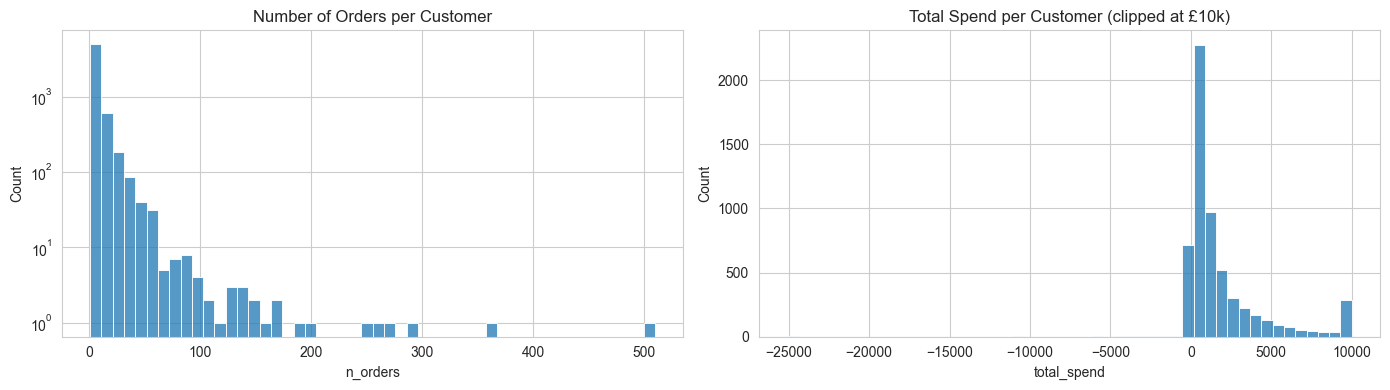

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(cust['n_orders'], bins=50, ax=axes[0])
axes[0].set_title('Number of Orders per Customer')
axes[0].set_yscale('log')
sns.histplot(cust['total_spend'].clip(upper=10000), bins=50, ax=axes[1])
axes[1].set_title('Total Spend per Customer (clipped at £10k)')
plt.tight_layout()
plt.show()

In [20]:
# Pareto check — what % of revenue comes from top 20% of customers?
cust_sorted = cust.sort_values('total_spend', ascending=False)
top20_pct = int(len(cust_sorted) * 0.20)
top20_revenue_share = cust_sorted['total_spend'].head(top20_pct).sum() / cust_sorted['total_spend'].sum()
print(f"Top 20% of customers account for {top20_revenue_share:.1%} of revenue")

Top 20% of customers account for 77.4% of revenue


**Headline finding: top 20% of customers drive 77.4% of revenue.** 

A textbook Pareto distribution. This is the single most important 
business fact in the dataset: **value is concentrated, retention 
matters more than acquisition, and the segmentation we build needs 
to surface this concentration clearly.**

## 8 Returns analysis

Returns are encoded as cancellation invoices (we already established 
that). Here we check whether returns are distributed broadly across 
customers or concentrated in a few. The latter would suggest a 
distinct "frequent-returner" segment worth tracking.

In [21]:
# Return rate
df['IsReturn'] = df['Invoice'].astype(str).str.startswith('C')
return_rate = df['IsReturn'].mean()
print(f"Overall return rate (by transaction line): {return_rate:.2%}")

# By customer
customer_returns = df[df['Customer ID'].notna()].groupby('Customer ID')['IsReturn'].mean()
print(f"\nCustomers with returns: {(customer_returns > 0).sum():,}")
print(f"Customers with >20% return rate: {(customer_returns > 0.2).sum():,}")

Overall return rate (by transaction line): 1.83%

Customers with returns: 2,572
Customers with >20% return rate: 200


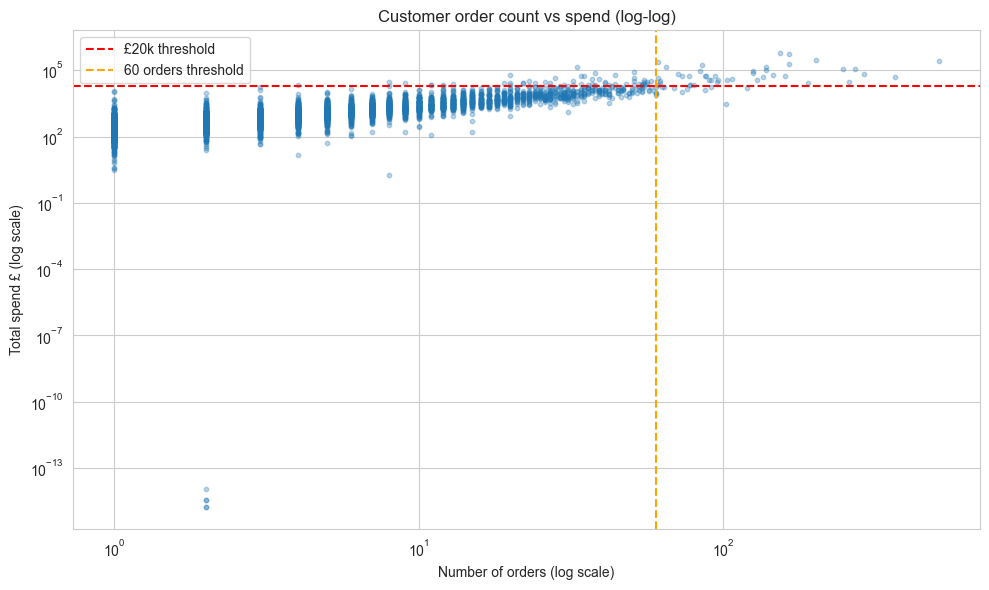

Customers with > 60 orders: 51
Customers with > £20,000 total spend: 94
Customers exceeding EITHER threshold: 103
Customers exceeding BOTH thresholds: 42


In [22]:
# Look at the high end of the distribution to find a natural break
high_spenders = cust[cust['total_spend'] > 0].sort_values('total_spend', ascending=False)

# Plot order count vs spend, log scale, to spot the wholesale outliers
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(high_spenders['n_orders'], high_spenders['total_spend'], alpha=0.3, s=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of orders (log scale)')
ax.set_ylabel('Total spend £ (log scale)')
ax.set_title('Customer order count vs spend (log-log)')
ax.axhline(20000, color='red', linestyle='--', label='£20k threshold')
ax.axvline(60, color='orange', linestyle='--', label='60 orders threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Count customers above each threshold
print(f"Customers with > 60 orders: {(cust['n_orders'] > 60).sum()}")
print(f"Customers with > £20,000 total spend: {(cust['total_spend'] > 20000).sum()}")
print(f"Customers exceeding EITHER threshold: {((cust['n_orders'] > 60) | (cust['total_spend'] > 20000)).sum()}")
print(f"Customers exceeding BOTH thresholds: {((cust['n_orders'] > 60) & (cust['total_spend'] > 20000)).sum()}")

**No natural gap.** The scatter shows a continuous gradient from 
typical retail customers up through wholesale accounts — no clear 
visual cutoff. The wholesale/retail distinction is a *convention*, 
not a hard line in the data.

**Threshold chosen:** customers with **>60 orders OR >£20,000 lifetime 
spend** are classified as wholesale (103 customers, 1.7% of base). 
This is a practical cutoff that cleanly excludes the visibly wholesale 
population while keeping the long tail of retail customers intact.

## 9 Wholesale vs retail split

The top spenders look like wholesale accounts. Before committing to 
a split, we look at the joint distribution of order count and total 
spend in log-log space — wholesale customers should appear as outliers 
above the retail cloud. The goal is to find a natural gap if one 
exists, or pick a defensible threshold if it doesn't.

In [23]:
wholesale_mask = (cust['n_orders'] > 60) | (cust['total_spend'] > 20000)
wholesale = cust[wholesale_mask]
retail = cust[~wholesale_mask & (cust['total_spend'] > 0)]

print(f"Wholesale: {len(wholesale)} customers, £{wholesale['total_spend'].sum():,.0f} revenue ({wholesale['total_spend'].sum()/cust['total_spend'].sum():.1%})")
print(f"Retail: {len(retail)} customers, £{retail['total_spend'].sum():,.0f} revenue ({retail['total_spend'].sum()/cust['total_spend'].sum():.1%})")

Wholesale: 103 customers, £6,136,214 revenue (36.9%)
Retail: 5739 customers, £10,606,217 revenue (63.7%)


**A second headline finding: 103 wholesale customers (1.7% of the 
customer base) drove 37% of historical revenue.** 

This is a major concentration story on its own. For the segmentation 
project, splitting them out is the right call — a 5-person cluster 
of wholesalers wouldn't yield actionable marketing strategies. They're 
preserved as a separate dataset for top-accounts reporting.

**Retail base for downstream analysis: 5,739 customers, £10.6M historical 
revenue.** (Note: further cleaning steps will narrow this to ~5,248 
when customers whose transactions are entirely non-product / non-UK / 
zero-price are removed.)

## EDA Summary

### Scale
- **1,067,371 transactions** across Dec 2009 – Dec 2011
- **5,942 unique customers**, UK-focused retailer of giftware

### Data quality issues identified
- **22% of rows have missing Customer ID** → drop (fatal for segmentation)
- **2.15% negative quantities**, of which 85% are cancellation invoices 
  ("C" prefix) and 15% are inventory adjustments (all with missing IDs, 
  covered by the missing-ID drop)
- **6,207 zero/negative-price rows** → drop (administrative, non-product)
- **Non-product stock codes** (POST, BANK CHARGES, AMAZONFEE, DOT, M, D) → drop
- **85 customers (1.4%) with negative lifetime spend** → exclude

### Scope decisions
- **Filter to UK only** — 92% of revenue, consistent customer base
- **Split wholesale from retail** at threshold of >60 orders OR >£20k 
  spend (103 customers identified)

### Business patterns
- **Top 20% of customers drive 77.4% of revenue** — strong Pareto
- **Wholesale customers (1.7% of base) drive 37% of historical revenue** — 
  extreme concentration justifying the split
- **Heavy right-skew** across all customer-level metrics (mean/median 
  ratio ≈ 3.3x for spend)
- **No Saturday operations** (zero revenue) — rules out "weekend behavior" 
  as a useful feature
- **Strong seasonality** with Oct-Nov peaks and January troughs
- **2,572 customers (43%) have any returns**; 200 customers (3.4%) have 
  return rate >20% — small but distinct subgroup

### Implications for downstream work
- **Cleaning** must: drop missing IDs, drop cancellations, drop non-product 
  SKUs, drop non-positive prices, filter to UK, split wholesale, remove 
  non-positive-spend customers
- **Feature engineering** should capture RFM + tenure + AOV + product 
  breadth; skip weekend-behavior features
- **Clustering** must log-transform skewed features before scaling; 
  expect a distinct one-time-buyer cluster from the 28% of customers with 
  only one order
- **CLV modeling** will struggle with single-order customers (no repeat 
  history for BG/NBD) — this is a known limitation to surface in the README

### Final retail base
**~5,248 customers** after all cleaning steps applied (verified in 
notebook 02), driving £10.6M in historical revenue.